In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import imutils
import pandas as pd
import matplotlib
import random
from skimage.morphology import skeletonize
from fil_finder import FilFinder2D
import astropy.units as u
from scipy import ndimage
from scipy import ndimage as ndi
from sklearn.metrics import pairwise_distances
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")
%matplotlib notebook

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



<IPython.core.display.Javascript object>


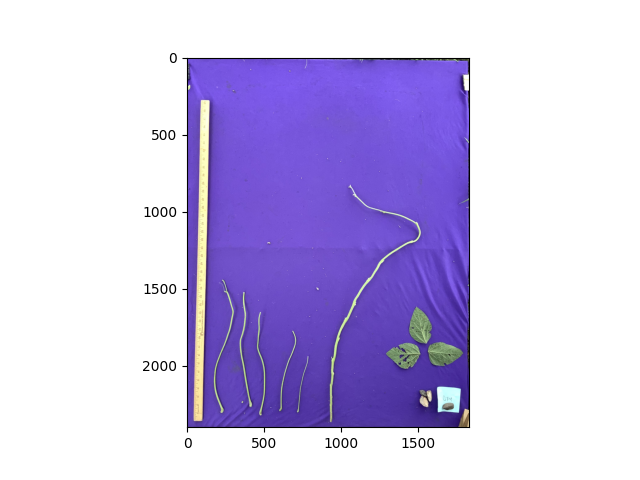

In [21]:
#im = cv.imread("/Users/quino070/AppleScans/Leaf/L_1022-53_R1_S001.jpg")
im = cv.imread("/Users/quino070/SoyArchAnalysis/testimages/IMG_1478.jpeg")
im = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im = im[400:2800, 400:2230]

plt.figure()
plt.imshow(im)

In [3]:
# Segment using text prompt
inputs = processor(images=[im,im], text=["leaf", "stem"], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.62,
    mask_threshold=0.62,
    target_sizes=inputs.get("original_sizes").tolist()
)

print(f"Image 1: {len(results[0]['masks'])} objects found")
print(f"Image 2: {len(results[1]['masks'])} objects found")

Image 1: 4 objects found
Image 2: 6 objects found


In [22]:
stemmasks = results[1]["masks"]
#filter out incorrect masks
filtered_mask_ids = []
for idx, mask in enumerate(stemmasks):
    if mask[0:1500, 1700:2000].sum()==0:
        filtered_mask_ids.append(idx)
stemmasks= stemmasks[filtered_mask_ids]
stemboxes = results[1]["boxes"][filtered_mask_ids]

In [25]:
for stem in stemmasks:
    print(stem.sum())

tensor(31425)
tensor(2887)
tensor(10910)
tensor(7213)
tensor(8909)
tensor(5020)


<IPython.core.display.Javascript object>


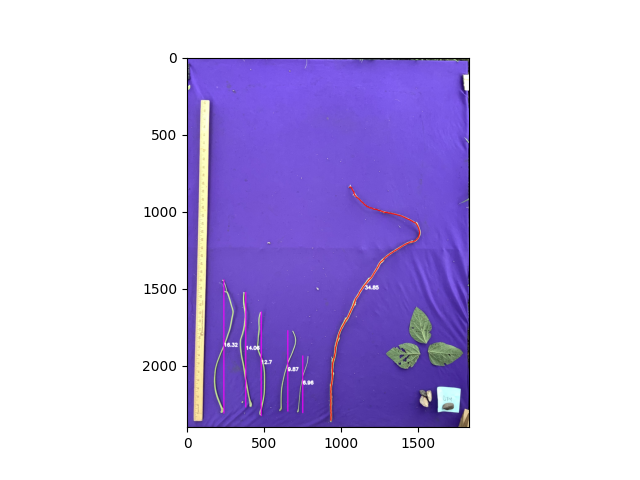

In [26]:
stem_df = []
out_im = im.copy()
for idx,stem in enumerate(stemmasks):
    stem = np.array(stem, np.uint8)
    if stem.sum()>15000:
        skeleton = skeletonize(stem)
        fil = FilFinder2D(stem, mask=skeleton)
        fil.medskel(verbose=False)
        fil.analyze_skeletons(skel_thresh=50*u.pix, branch_thresh=10*u.pix,
                              prune_criteria='length', max_prune_iter=1)
        skel = np.asarray(fil.skeleton_longpath).squeeze()
        length = round(np.count_nonzero(skel)/53,2)
        
        contours, _ = cv.findContours(
        np.array(fil.skeleton_longpath, np.uint8),
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_NONE
        )

        cv.drawContours(out_im, contours[0], -1, (255,0,0), 5)
        
        #Draw line analyzed
        skel = fil.skeleton_longpath.squeeze().astype(np.uint8)
        ys, xs = np.nonzero(skel)
        cx = int(xs.mean())
        cy = int(ys.mean())

        cv.putText(out_im, str(length), (cx,cy), cv.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 5)
        
    else:
        stem = np.array(stem, np.uint8)
        [x0,y0,x1,y1] = np.array(stemboxes[idx]).astype(int)
        h = y1-y0
        length = round(h/53,2)
        
 
        contours, _ = cv.findContours(
            stem,
            cv.RETR_EXTERNAL,
            cv.CHAIN_APPROX_NONE
        )
        #cont = max(contours, key=cv.contourArea)
        w = x1-x0
        cv.line(out_im, (x0+(w//2),y0),(x0+(w//2),y1), (255,0,255), 6)
        cv.putText(out_im, str(length), (x0+(w//2), y0+(h//2)), cv.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 5)

    
        #Save length
    stem_df.append({
        'Object': f"stem_{idx + 1}",    
        'Trait': "Length(cm)",
        'Value': length
        
    })

plt.figure()
plt.imshow(out_im)

In [52]:
leafmasks = results[0]["masks"]
#filter out incorrect masks
filtered_mask_ids = []
for idx, mask in enumerate(leafmasks):
    if np.array(mask.sum() >=10000):
        filtered_mask_ids.append(idx)
    
leafmasks= leafmasks[filtered_mask_ids]
result_boxes = results[0]["boxes"][filtered_mask_ids]

<IPython.core.display.Javascript object>


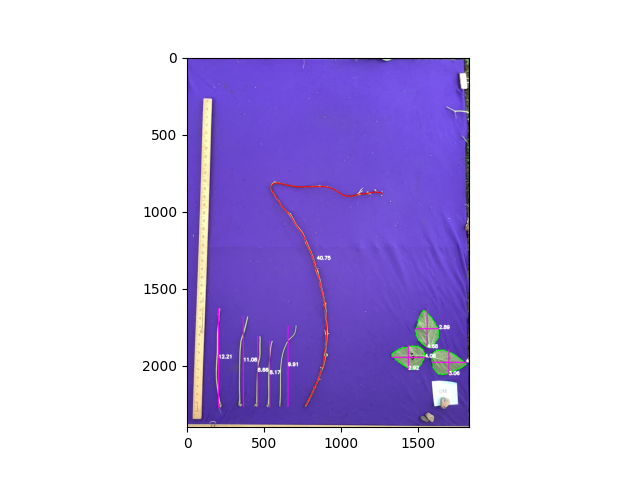

In [53]:
leaf_df = []
for idx,leaf in enumerate(leafmasks):
    leaf = np.array(leaf, np.uint8)*255
    #Get height and width
    [x0,y0,x1,y1] = np.array(result_boxes[idx]).astype(int)
    m1 = x1-x0
    m2 = y1-y0
    
    if m1<m2:
        width, height = m1,m2
        w0,w1, h0, h1 = x0,x1,y0,y1
    else:
        width, height = m2,m1
        w0,w1, h0, h1 = y0,y1,x0,x1
    
    #Get area
    contours, _ = cv.findContours(
        np.array(leaf, np.uint8),
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_NONE
    )
    
    leaf_area = cv.contourArea(contours[0])
    
    #Save traits
    leaf_df.append({
        'Object': f"leaflet_{idx + 1}",    
        'Area(cm2)': round(leaf_area/(53*53),2),
        'Height(cm)': round(height/53,2),
        'Width(cm)': round(width/53,2)
        
    })
    
    #Draw measurements
    leaf = cv.cvtColor(leaf, cv.COLOR_GRAY2BGR)
    cv.drawContours(out_im, contours, -1, (0,255,0), 6)
    cv.line(out_im, (x0+(m1//2), y0), (x0+(m1//2),y0+m2), (255,0,255), 6)
    cv.putText(out_im, str(round(m2/53,2)), (x0+(m1//2),y0+m2), cv.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 5)
    cv.line(out_im, (x0, y0+(m2//2)), (x1,y0+(m2//2)), (255,0,255), 6)
    cv.putText(out_im, str(round(m1/53,2)), (x1,y0+(m2//2)), cv.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 5)

plt.figure()
plt.imshow(out_im)

In [54]:
full_df = pd.concat([
    pd.DataFrame(stem_df), 
    pd.melt(pd.DataFrame(leaf_df), 
            id_vars=['Object'], 
            var_name='Trait', 
            value_name='Value')
])

In [55]:
full_df

,Object,Trait,Value
0,stem_1,Length(cm),8.17
1,stem_2,Length(cm),12.21
2,stem_3,Length(cm),9.91
3,stem_4,Length(cm),11.08
4,stem_5,Length(cm),8.66
5,stem_6,Length(cm),40.75
0,leaflet_1,Area(cm2),8.50
1,leaflet_2,Area(cm2),8.51
2,leaflet_3,Area(cm2),7.89
3,leaflet_1,Height(cm),4.17
